# Session 4 - ML

## Subjects :  GD - SGD- Mini batch SGD -Train-test split - hyperparameters - hyperparameter tuning up -SGDRegressor

## Stochastic Gradient Descent  - SGD

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor


In [3]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([20, 22, 29, 30, 35]).reshape(-1, 1)

In [4]:
# Hyperparametes
max_iter = 100
lr = 0.0001
a, b = 0,0
thetas = [[b],[a]]

# Add bias 
X_bias = np.c_[np.ones((5,1)),X]

m = len(X_bias)
cost_function=[]

In [5]:
# np.random.permutation
np.random.permutation(m)

array([1, 2, 0, 3, 4])

array([[ 1., 40.]])

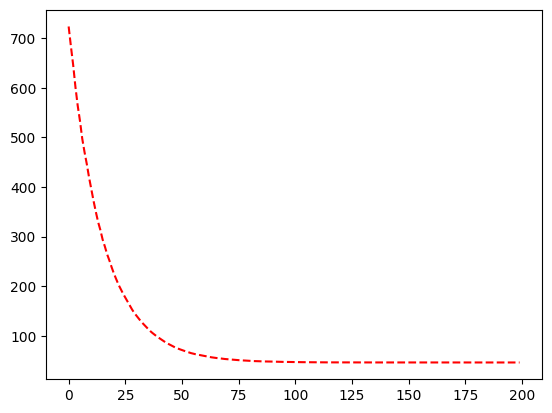

In [26]:
# SGD trin loop 
for epoch in range (max_iter):
    #Shuffle X and y together
    indices = np.random.permutation(m)
    X_shuffled = X_bias[indices]
    y_shuffled = y[indices]

    for i in range(m):
        #X_i = X_shuffled[i:i+1]    # we use like this for keeping shape 2D for @
        X_i = X_shuffled[i].reshape(1,-1)  # or use this
        y_i = y_shuffled[i].reshape(1,1)  

        y_pred = X_i @ thetas
        error = y_pred - y_i
        gd =  X_i.T @ error
        thetas = thetas - lr *gd

    # After each epoch, calculate cost on ALL data
    y_pred_all = X_bias @ thetas
    mse = np.mean(np.square(y - y_pred_all))
    cost_function.append(mse)

plt.plot(cost_function,'r--')
    

X_i.shape
X_i
        

    

In [14]:
''

''

## mini batch SGD

Final theta: [0.02787427 0.75926848]


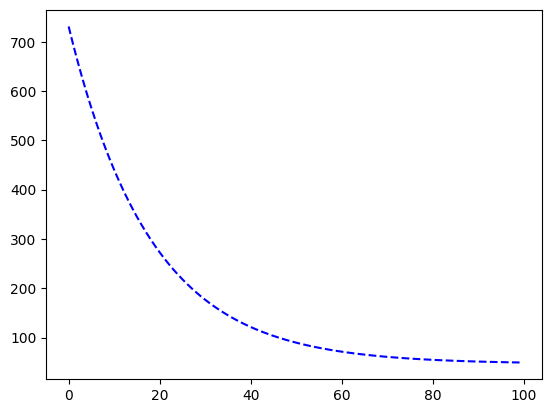

In [29]:
import numpy as np

X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
y = np.array([20, 22, 29, 30, 35]).reshape(-1, 1)

# Add bias column
X_bias = np.c_[np.ones((5, 1)), X]

m = len(X_bias)
max_iter = 100
learning_rate = 0.00001
batch_size = 2
thetas = np.zeros((2, 1))

cost_function = []

for epoch in range(max_iter):
    # Shuffle X and y TOGETHER
    indices = np.random.permutation(m)
    X_shuffled = X_bias[indices]
    y_shuffled = y[indices]
    
    # Mini-batch loop
    for i in range(0, m, batch_size):
        x_batch = X_shuffled[i:i+batch_size]   # (batch_size, 2)
        y_batch = y_shuffled[i:i+batch_size]   # (batch_size, 1)
        
        h = x_batch @ thetas                    # Predictions
        error = h - y_batch                     # Error (same batch size)
        gradient = x_batch.T @ error / batch_size
        thetas = thetas - learning_rate * gradient
    
    # Cost on ALL data after each epoch
    y_pred_all = X_bias @ thetas
    mse = np.mean(np.square(y - y_pred_all))
    cost_function.append(mse)

print("Final theta:", thetas.ravel())
plt.plot(cost_function,"b--")

## SGDRegressor 

In [41]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [42]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=0.6,
    effective_rank=21,
    tail_strength=0.5
)

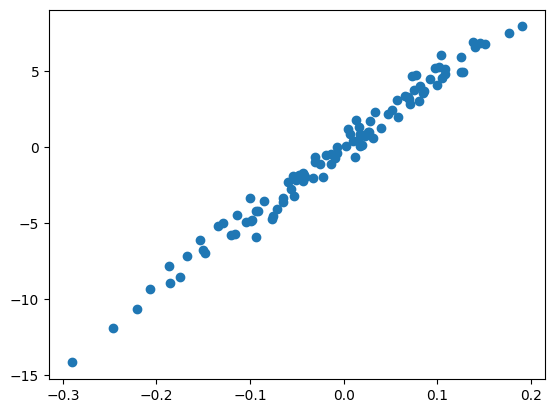

In [43]:
plt.scatter(X,y)

In [44]:
model = SGDRegressor(
    learning_rate="constant",
    eta0=0.15,
    max_iter=300,
    tol=1e-10,
    verbose=True
)

In [45]:
# Train
model.fit(X,y)

-- Epoch 1
Norm: 5.94, NNZs: 1, Bias: -0.170236, T: 100, Avg. loss: 9.465007
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 11.51, NNZs: 1, Bias: 0.098326, T: 200, Avg. loss: 7.782505
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 16.38, NNZs: 1, Bias: -0.262286, T: 300, Avg. loss: 5.902529
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 20.47, NNZs: 1, Bias: -2.423482, T: 400, Avg. loss: 4.202311
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 23.87, NNZs: 1, Bias: -1.149630, T: 500, Avg. loss: 3.170109
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 26.98, NNZs: 1, Bias: 0.300849, T: 600, Avg. loss: 2.561762
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 29.72, NNZs: 1, Bias: -0.580285, T: 700, Avg. loss: 1.978564
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 31.98, NNZs: 1, Bias: -0.899796, T: 800, Avg. loss: 1.477230
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 33.86, NNZs: 1, Bias: -0.365706, T: 900, Avg. loss: 1.152589
Total training time: 

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,300
,tol,1e-10
,shuffle,True
,verbose,True
,epsilon,0.1
,random_state,None


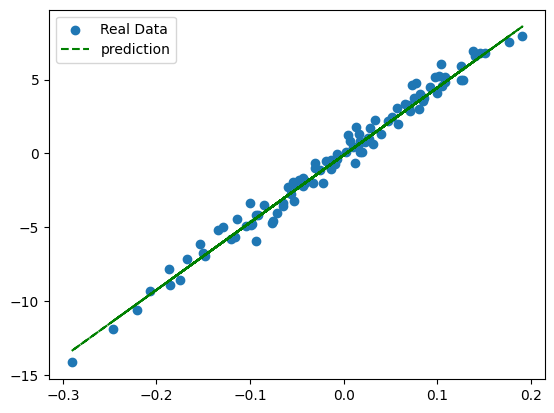

In [46]:
# Predict 0.601291 0.526645 0.373634
y_pred = model.predict(X)

plt.scatter(X,y, label="Real Data")
plt.plot(X,y_pred, "g--", label="prediction")
plt.legend()

## Hyperparameter Tune Up

In [47]:
for l_r in np.arange(0.01,.04,0.01):
    for max_it in [50,150,200,500,1000,5000,10000]:
        model = SGDRegressor(
            learning_rate = 'constant',
            eta0 = l_r,
            max_iter = max_it,
            tol=1e-10,
            random_state=42  # ← Same result every run!

        )

        model.fit(X,y)
        y_pred = model.predict(X)

        mse = mean_squared_error(y,y_pred)
        print(f"Learning rate = {l_r} - Max Iter = {max_it} - MSE = {mse}")


#Compare __ best lr and max_iter : Learning rate = 0.03 - Max Iter = 150 - MSE = 0.36585095861926525



Learning rate = 0.01 - Max Iter = 50 - MSE = 8.191883269586532
Learning rate = 0.01 - Max Iter = 150 - MSE = 1.479871037685752
Learning rate = 0.01 - Max Iter = 200 - MSE = 0.7993793349858248
Learning rate = 0.01 - Max Iter = 500 - MSE = 0.38995479575529585
Learning rate = 0.01 - Max Iter = 1000 - MSE = 0.38995479575529585
Learning rate = 0.01 - Max Iter = 5000 - MSE = 0.38995479575529585
Learning rate = 0.01 - Max Iter = 10000 - MSE = 0.38995479575529585
Learning rate = 0.02 - Max Iter = 50 - MSE = 3.285190618326092
Learning rate = 0.02 - Max Iter = 150 - MSE = 0.43809941678898456
Learning rate = 0.02 - Max Iter = 200 - MSE = 0.3912648144127657
Learning rate = 0.02 - Max Iter = 500 - MSE = 0.3912648144127657
Learning rate = 0.02 - Max Iter = 1000 - MSE = 0.3912648144127657
Learning rate = 0.02 - Max Iter = 5000 - MSE = 0.3912648144127657
Learning rate = 0.02 - Max Iter = 10000 - MSE = 0.3912648144127657
Learning rate = 0.03 - Max Iter = 50 - MSE = 1.4678867564573566
Learning rate = 0.

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

## Train-test split - for regression (time series or not time-series) - classification

In [48]:
from sklearn.model_selection import train_test_split
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1,1)
y = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])


In [49]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8,shuffle = True)

# when your data is time series like BTC or bllod presure you have use shuffle = FALSE)

print("Train :", x_train, y_train)
print("Test :", x_test, y_test)


Train : [[7]
 [5]
 [6]
 [1]
 [2]
 [3]
 [9]
 [8]] [700 500 600 100 200 300 900 800]
Test : [[ 4]
 [10]] [ 400 1000]


In [50]:
# Train
model.fit(x_train, y_train)

# Prediction (test)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# Evaluate (test)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred) # This is matter for evaluate our model

In [51]:
# Use "stratify " when your data are 0,1,2,... ( Clasiffication models)
# shuffle must be TRUE 
labels = {0:"cat", 1:"dog"}

X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,11,12])
y = np.array([0,0,0,0,0,1,1,1,1,1,1,1])

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8,shuffle=True,stratify=y)

print("X_train", x_train, y_train)
print("X_test", x_test, y_test)



X_train [ 9  3  1 10 12  5  8  2  6] [1 0 0 1 1 0 1 0 1]
X_test [ 7 11  4] [1 1 0]
